# Day 7. Transformer

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Scaled Dot-Product Attention 구현

In [9]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        """
        Q: (batch, L_q, d_k)
        K: (batch, L_k, d_k)
        V: (batch, L_k, d_v)
        mask: (batch, L_q, L_k) or (1, L_q, L_k), 0 또는 -inf 마스킹용
        """
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        output = torch.matmul(attn, V)
        return output, attn


## Multi-Head Attention 구현 (batch_first = True 가정)

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        """
        x: (B, L, d_model)  -- self-attention 입력
        mask: (B, L, L) or (1, L, L)
        """
        B, L, _ = x.size()

        residual = x

        # 1) Linear projections
        Q = self.W_q(x)  # (B, L, d_model)
        K = self.W_k(x)
        V = self.W_v(x)

        # 2) head 나누기
        # (B, L, num_heads, d_k) -> (B, num_heads, L, d_k)
        def split_heads(t):
            return t.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

        Q = split_heads(Q)
        K = split_heads(K)
        V = split_heads(V)

        if mask is not None:
            # mask: (B, L, L) -> (B, 1, L, L) for broadcasting
            mask = mask.unsqueeze(1)

        # 3) attention
        context, attn = self.attention(Q, K, V, mask=mask)  # context: (B, num_heads, L, d_k)

        # 4) concat heads
        context = context.transpose(1, 2).contiguous().view(B, L, self.d_model)

        # 5) final linear + residual + layer norm
        output = self.fc(context)
        output = self.dropout(output)
        output = self.layer_norm(output + residual)

        return output, attn


## Position-wise Feed-Forward Network

In [11]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        x = self.layer_norm(x + residual)
        return x


## Transformer Encoder Block

In [12]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

    def forward(self, x, src_mask=None):
        """
        x: (B, L, d_model)
        src_mask: (B, L, L) or (1, L, L)
        """
        x, attn = self.self_attn(x, mask=src_mask)
        x = self.ffn(x)
        return x, attn


## Transformer Encoder Block 간단 테스트

In [13]:
batch_size = 2
seq_len = 5
d_model = 16

x = torch.randn(batch_size, seq_len, d_model).to(device)  # toy input

block = TransformerEncoderBlock(
    d_model=d_model, num_heads=4, d_ff=64, dropout=0.1
).to(device)

out, attn = block(x)

print("Input shape :", x.shape)       # (2, 5, 16)
print("Output shape:", out.shape)     # (2, 5, 16)
print("Attention shape:", attn.shape) # (2, num_heads, L, L)


Input shape : torch.Size([2, 5, 16])
Output shape: torch.Size([2, 5, 16])
Attention shape: torch.Size([2, 4, 5, 5])


## Sin-Cos Positional Encoding

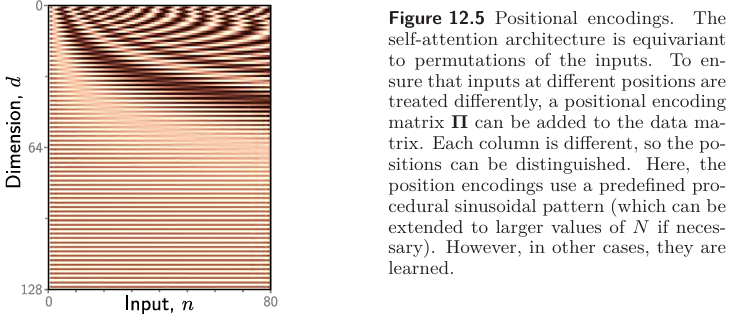

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: (B, L, d_model)
        """
        L = x.size(1)
        x = x + self.pe[:, :L]
        return x


## Encoder-Decoder Transformer (PyTorch 기본 모듈 활용)

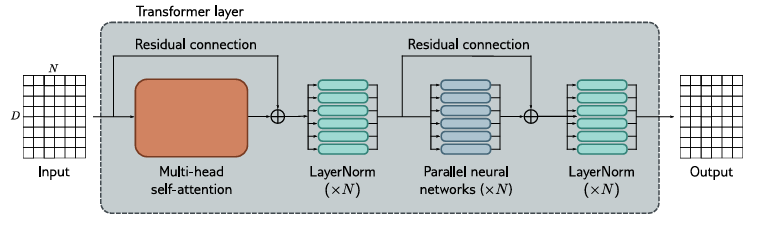

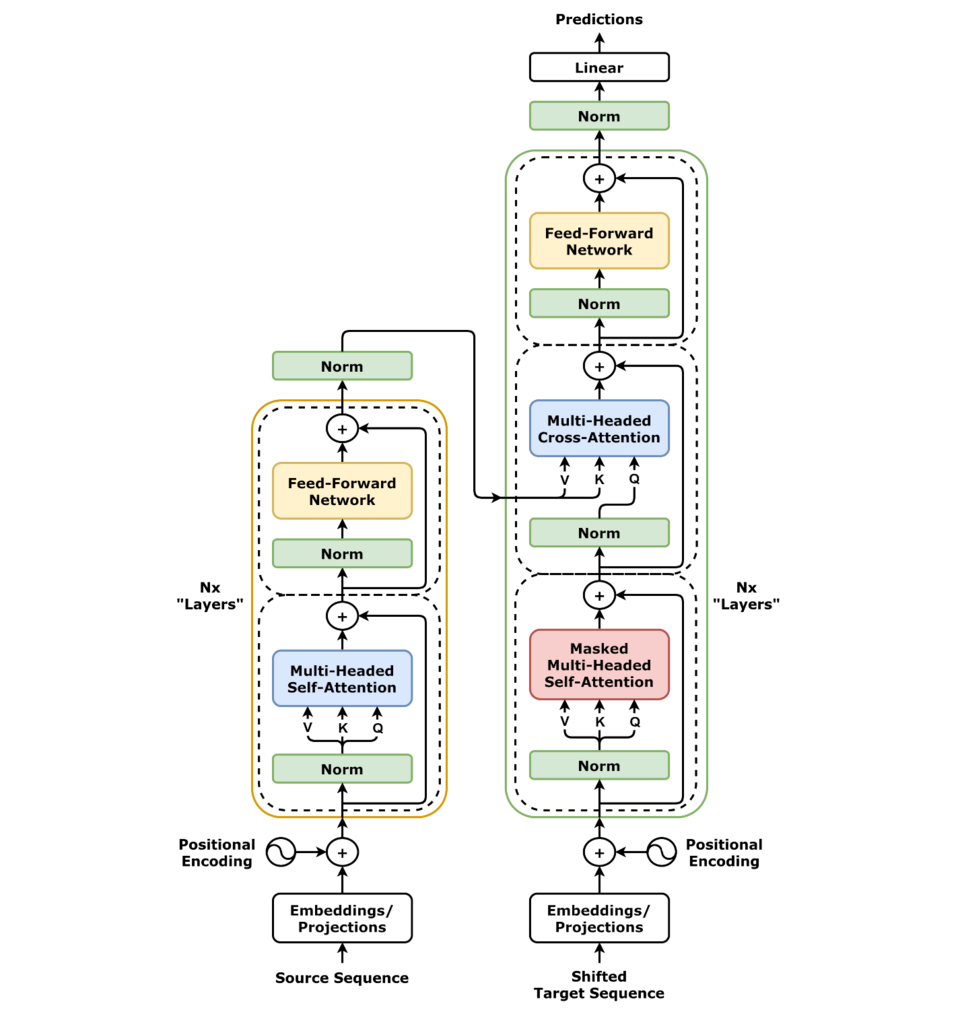

In [15]:
class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_tokens_src: int,
        num_tokens_tgt: int,
        d_model: int = 128,
        nhead: int = 4,
        num_encoder_layers: int = 2,
        num_decoder_layers: int = 2,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        max_len: int = 100,
    ):
        super().__init__()

        self.d_model = d_model

        self.src_embed = nn.Embedding(num_tokens_src, d_model)
        self.tgt_embed = nn.Embedding(num_tokens_tgt, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_decoder_layers,
        )

        self.generator = nn.Linear(d_model, num_tokens_tgt)

    def make_src_mask(self, src):
        src_pad_mask = (src == 0)
        return src_pad_mask

    def make_tgt_mask(self, tgt):
        L = tgt.size(1)
        mask = torch.triu(torch.ones(L, L), diagonal=1).bool()
        return mask

    def forward(self, src, tgt):
        B, L_src = src.shape
        B, L_tgt = tgt.shape

        src_mask = None
        tgt_mask = self.make_tgt_mask(tgt).to(src.device)
        src_key_padding_mask = self.make_src_mask(src)
        tgt_key_padding_mask = (tgt == 0)

        # ↓↓↓ math.sqrt → np.sqrt 로 변경
        src_emb = self.positional_encoding(
            self.src_embed(src) * np.sqrt(self.d_model)
        )
        tgt_emb = self.positional_encoding(
            self.tgt_embed(tgt) * np.sqrt(self.d_model)
        )

        memory = self.encoder(
            src_emb,
            mask=src_mask,
            src_key_padding_mask=src_key_padding_mask,
        )

        out = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )

        logits = self.generator(out)
        return logits


In [16]:
vocab_src = 50
vocab_tgt = 50
model = Seq2SeqTransformer(
    num_tokens_src=vocab_src,
    num_tokens_tgt=vocab_tgt,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=512,
    dropout=0.1,
    max_len=50,
).to(device)

B = 4
L_src = 7
L_tgt = 6

src = torch.randint(1, vocab_src, (B, L_src)).to(device)
tgt = torch.randint(1, vocab_tgt, (B, L_tgt)).to(device)

logits = model(src, tgt)
print("src shape:", src.shape)      # (B, L_src)
print("tgt shape:", tgt.shape)      # (B, L_tgt)
print("logits shape:", logits.shape) # (B, L_tgt, vocab_tgt)


src shape: torch.Size([4, 7])
tgt shape: torch.Size([4, 6])
logits shape: torch.Size([4, 6, 50])


## Toy example : BERT sentence masking

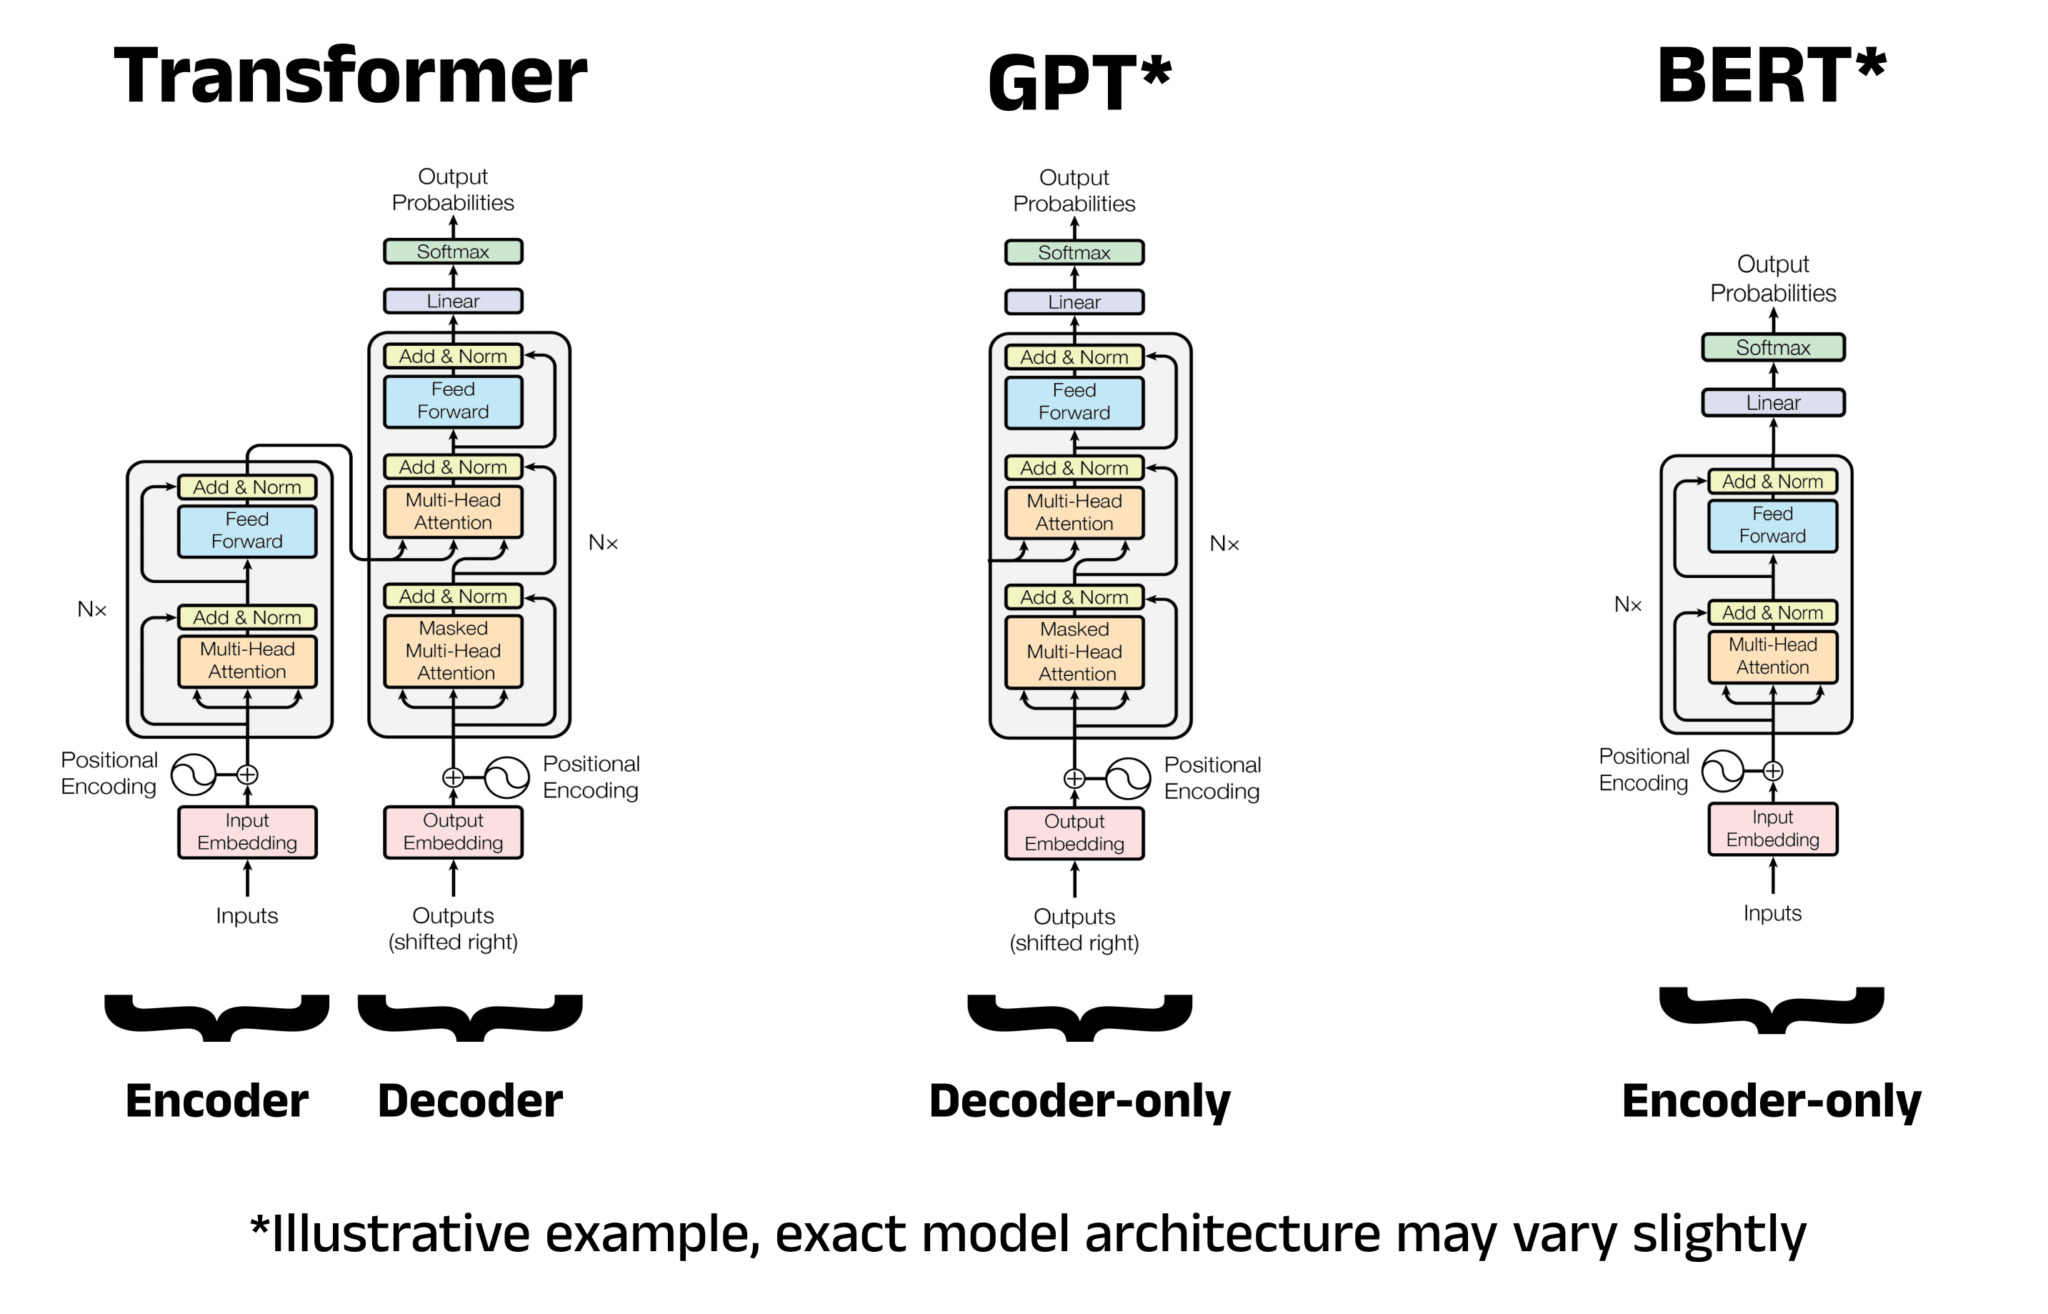

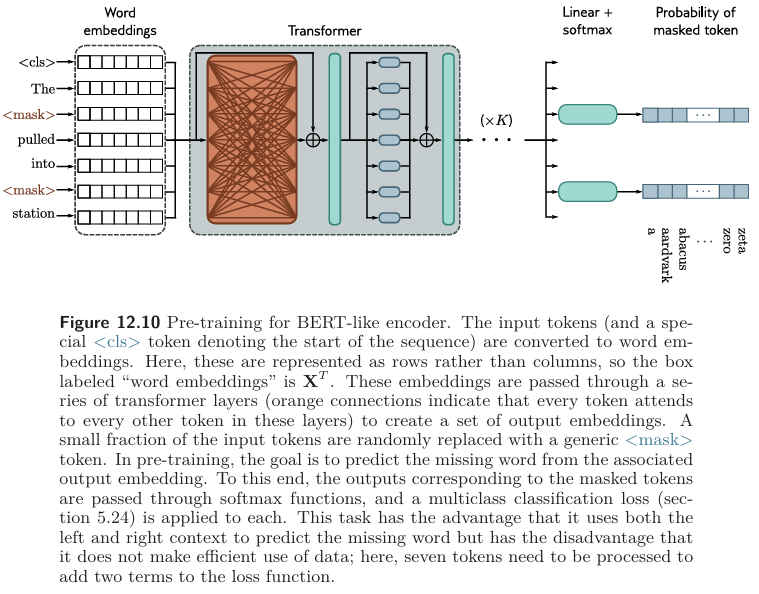

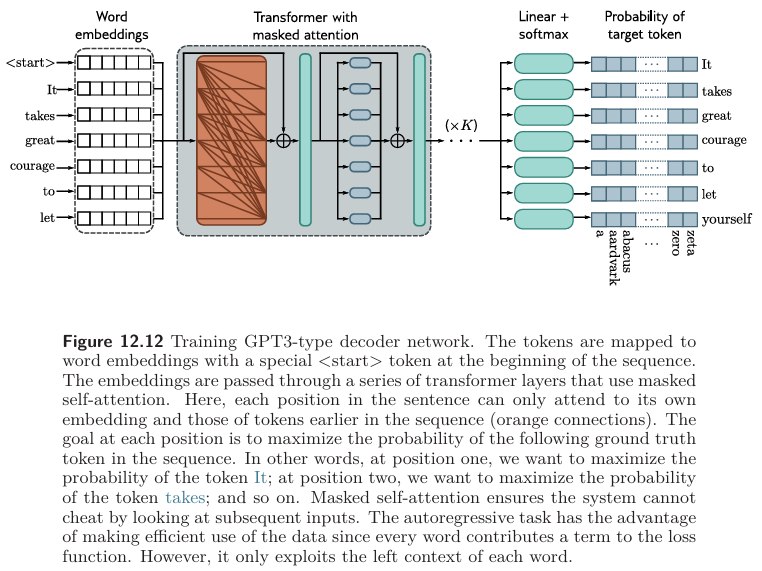

In [21]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline, set_seed

set_seed(42)

pre-trained BERT model loading

In [32]:
model_name = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)


Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [33]:
fill_mask = pipeline(
    "fill-mask",
    model=model,
    tokenizer=tokenizer
)

masking = tokenizer.mask_token

print("MASK token:", masking)

Device set to use cuda:0


MASK token: [MASK]


Masking example 1

In [41]:
# 문장 일부 마스킹
sentence = f"His {masking} was broken."

print("Input : ", sentence)

# 상위 5개 후보 출력
results = fill_mask(sentence, top_k=5)

for i, r in enumerate(results, start=1):
    print(f"{i}. {r['sequence']} (score={r['score']:.4f})")


Input :  His [MASK] was broken.
1. His shoulder was broken. (score=0.0260)
2. His hand was broken. (score=0.0257)
3. His heart was broken. (score=0.0191)
4. His record was broken. (score=0.0135)
5. His arm was broken. (score=0.0128)


Masking example 2

In [30]:
sentences = [
    f"I go to {masking}.",
    f"He can {masking} more then five different languages.",
    f"You are {masking} smart person."
]

for s in sentences:
    print("=" * 80)
    print("Input sentence :", s)
    results = fill_mask(s, top_k=3)
    for i, r in enumerate(results, start=1):
        print(f"{i}. {r['sequence']} (score={r['score']:.4f})")


Input sentence : I go to [MASK].
1. I go to school. (score=0.1137)
2. I go to work. (score=0.0430)
3. I go to go. (score=0.0370)
Input sentence : He can [MASK] more then five different languages.
1. He can learn more then five different languages. (score=0.5569)
2. He can speak more then five different languages. (score=0.1316)
3. He can have more then five different languages. (score=0.0246)
Input sentence : You are [MASK] smart person.
1. You are a smart person. (score=0.8946)
2. You are the smart person. (score=0.0570)
3. You are an smart person. (score=0.0155)


Step by Step

In [31]:
sentence = f"I go to {masking} today."

inputs = {k: v.to(device) for k, v in tokenizer(sentence, return_tensors="pt").items()}

# Masked position search
mask_token_index = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# logits of Masked position
mask_token_logits = logits[0, mask_token_index, :]

# 상위 5개 단어 id
top_k = 5
top_token_ids = torch.topk(mask_token_logits, top_k, dim=1).indices[0].tolist()

print("Input :", sentence)
print("\n[BERT prediction result(top 5)]")

for token_id in top_token_ids:
    token = tokenizer.decode([token_id])
    score = torch.softmax(mask_token_logits, dim=1)[0, token_id].item()

    filled_sentence = sentence.replace(tokenizer.mask_token, token)
    print(f"- {filled_sentence} (token='{token}', prob={score:.4f})")

Input : I go to [MASK] today.

[BERT prediction result(top 5)]
- I go to school today. (token='school', prob=0.2139)
- I go to it today. (token='it', prob=0.0521)
- I go to you today. (token='you', prob=0.0334)
- I go to go today. (token='go', prob=0.0299)
- I go to college today. (token='college', prob=0.0271)
